# TEA-seq: topic modeling of a RNA + ATAC + protein PMBCs

This tutorial runs **topomics** (`MultimodalAmortizedLDA`) on a tri-modal
[TEA-seq](https://elifesciences.org/articles/63632) dataset (paired single-cell
**RNA**, **ATAC**, and surface **protein**). It shows how to:

1. load the data and prepare the `MuData`,
2. *(training is shown for reference but commented out)* — we **load a model from disk**,
3. extract the cell-topic distribution &theta;,
4. inspect the top features per topic in each modality,
5. visualize topics on a UMAP, and
6. summarize topic usage per cell type.


## Configuration
Just some utilities to load a pre-trained model for this example

In [51]:
from pathlib import Path
import yaml


def load_config():
    """Load the git-ignored config.yml holding private dataset/model paths.

    Copy ``config.example.yml`` to ``config.yml`` and fill in your paths.
    """
    for p in (Path("config.yml"), Path("../config.yml"), Path("examples/config.yml")):
        if p.exists():
            return yaml.safe_load(p.read_text())
    raise FileNotFoundError("config.yml not found. Copy config.example.yml to config.yml and edit it.")


CONFIG = load_config()

cfg = CONFIG["datasets"]["teaseq"]

## Imports

In [52]:
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import matplotlib.pyplot as plt

from topomics import MultimodalAmortizedLDA

sc.settings.verbosity = 1
MODALITY_ORDER = ["rna", "atac", "prot"]

## Load data

The `MuData` holds three modalities, each with raw counts in `layers["counts"]`.
We restrict RNA/ATAC to highly variable features exactly as the model was trained,
and **binarize ATAC**.

In [53]:
mdata = mu.read_h5mu(cfg["data"])

sc.pp.highly_variable_genes(mdata.mod["rna"], n_top_genes=2000, flavor="seurat_v3", layer="counts")
mdata.mod["rna"] = mdata.mod["rna"][:, mdata.mod["rna"].var["highly_variable"]].copy()

sc.pp.highly_variable_genes(mdata.mod["atac"], n_top_genes=10000, flavor="seurat_v3", layer="counts")
mdata.mod["atac"] = mdata.mod["atac"][:, mdata.mod["atac"].var["highly_variable"]].copy()

# ATAC uses a Bernoulli likelihood -> encode peaks as presence/absence (0/1).
_atac = mdata.mod["atac"]
_atac.layers["counts"] = (_atac.layers["counts"] > 0).astype("float32")

mdata.update()
mdata

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0

MuData object with n_obs × n_vars = 5805 × 12046
  obs:	'sample', 'well', 'leiden_multiplex', 'leiden_mofa', 'celltypist_label', 'celltypist_confidence'
  var:	'highly_variable', 'gene_ids', 'feature_types', 'genome', 'interval'
  uns:	'leiden', 'leiden_mofa', 'leiden_mofa_colors', 'mofa', 'umap'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap'
  varm:	'LFs'
  obsp:	'mofa_connectivities', 'mofa_distances'
  3 modalities
    rna:	5805 x 2000
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltypist_label', 'celltypist_confidence'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'highly_variable_rank', 'variances', 'variances_norm'
      uns:	'hvg', 'leiden', 'leiden_colors', 'leiden_multiplex_colors', 'log1p', 'neighbors', 'pca', 'rna:leiden_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm'
      obsp:	'connectivities', 'distances'
    atac:	5805 x 10000
      obs:	'n_fragments', 'n_duplicate', 'n_mito', 'n_unique', 'altius_count', 'altius_frac', 'gene_bodies_count', 'gene_bodies_frac', 'peaks_count', 'peaks_frac', 'tss_count', 'tss_frac', 'barcodes', 'cell_name', 'well_id', 'chip_id', 'batch_id', 'pbmc_sample_id', 'DoubletScore', 'DoubletEnrichment', 'TSSEnrichment', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'highly_variable_rank', 'variances', 'variances_norm'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm'
      obsp:	'connectivities', 'distances'
    prot:	5805 x 46
      obs:	'total_counts'
      var:	'highly_variable'
      uns:	'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

## Register the MuData with topomics

In [54]:
mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
    mdata,
    modality_order=MODALITY_ORDER,
    layers="counts",  # remember to specify the layer the data is stored in
    # or the model will select .X
)
print("modalities:", modality_names, "| feature counts:", feat_counts)

modalities: ['rna', 'atac', 'prot'] | feature counts: [2000, 10000, 46]


## Training (for reference — skipped here)

This is how the model was trained. In this tutorial we assume that we have already trained the model. Uncomment to train from scratch
(needs a GPU and a few minutes).

In [55]:
# model = MultimodalAmortizedLDA.from_mudata(
#     mdata,
#     modality_order=MODALITY_ORDER,
#     layers="counts",
#     n_topics=20,
#     likelihoods=["gamma_poisson", "bernoulli", "gamma_poisson"],
#     cell_topic_prior=1 / 20,
# )
# model.train(max_epochs=200, batch_size=256)
# model.save(cfg["model"], overwrite=True)

## Load the trained model

`load` needs an AnnData with the same feature layout used at training time.
`setup_mudata` already stored that flattened AnnData under
`mdata.uns["_flattened_ann_data"]`, so we reuse it directly.

In [56]:
adata_flat = mdata_setup.uns["_flattened_ann_data"]
model = MultimodalAmortizedLDA.load(cfg["model"], adata=adata_flat)
model

INFO     File                                                                                                      
         /data/omics_topic_models/teaseq_2.0/logistic_normal_moe_cell/prior_logistic_normal_weight_cell_learnable_d
         isp_pergene/model/model.pt already downloaded                                                             


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scvi/model/base/_base_model.py:830: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:163: RuntimeWarning: trying to observe a value outside of inference at topic_variance_bonus
  warnings.warn(


Epoch 1/1000:   0%|          | 1/1000 [00:00<01:06, 14.96it/s, v_num=1]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 2 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_1', 'topics_2', 'topics_0'}
  warnings.warn(
`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<01:11, 14.01it/s, v_num=1]


Training status: Trained

## Cell-topic distribution &theta;

`get_latent_representation` returns the (cells x topics) matrix. With
`return_dataframe=True` we get topic-labeled columns indexed by cell.

Notice that in principle we are approximating a posterior distribution for each point, but in this case we simply take the average, without sampling.

In [57]:
theta = model.get_latent_representation(batch_size=mdata.n_obs, return_dataframe=True)
print("theta shape:", theta.shape)
theta.head()

theta shape: (5805, 10)


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
AAACAGCCAATTAAGG-1,0.174442,0.007398,0.153438,0.166352,0.180219,0.010132,0.153502,0.121624,0.007727,0.025167
AAACAGCCACCCTCAC-1,0.180788,0.009597,0.152533,0.181792,0.188855,0.006604,0.197608,0.050097,0.011024,0.021102
AAACAGCCAGCTCAAC-1,0.156339,0.011893,0.189569,0.163712,0.171924,0.010939,0.183209,0.067951,0.010783,0.033682
AAACAGCCAGTATGTT-1,0.025995,0.181268,0.163482,0.025100,0.016614,0.011691,0.166433,0.122099,0.281996,0.005322
AAACAGCCATCAATCG-1,0.043409,0.155075,0.179874,0.050378,0.031177,0.014819,0.222904,0.079410,0.211628,0.011327


## Top features per topic

In [58]:
def top_features_per_topic(model, mdata, modality_order, n_top=10, n_samples=2000):
    """Return a dict {modality: DataFrame(topic x rank) of feature names}.

    ``model.module.topic_by_feature()`` gives E[phi_{k,m}] as a dict
    {modality_index: tensor (n_topics, n_features_m)}; we map columns back to
    the per-modality ``var_names``.
    """
    import numpy as np

    tbf = model.module.topic_by_feature(n_samples=n_samples)
    out = {}
    for m, mod in enumerate(modality_order):
        phi = np.asarray(tbf[m])  # (n_topics, n_features_m)
        var_names = np.asarray(mdata.mod[mod].var_names)
        rows = {}
        for k in range(phi.shape[0]):
            top_idx = np.argsort(phi[k])[::-1][:n_top]
            rows[f"topic_{k}"] = var_names[top_idx]
        out[mod] = pd.DataFrame(rows).T
        out[mod].columns = [f"rank_{i + 1}" for i in range(n_top)]
    return out


top = top_features_per_topic(model, mdata, MODALITY_ORDER, n_top=10)
print("Top RNA genes per topic:")
top["rna"].head()

Top RNA genes per topic:


,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9,rank_10
topic_0,CD28,TRAT1,BICDL1,ICOS,TNFAIP3,ZFPM1,PBX4,CDC14A,GATA3,BCL11B
topic_1,HLA-DRB1,CDK14,HLA-DRB5,GRK3,MYO1E,HLA-DRA,LYN,TBC1D9,TRIO,HLA-DPA1
topic_2,WWOX,ABCA6,ATP8A1,FBXL17,AC010996.1,KCNQ5,SMYD3,GMDS-DT,GNPTAB,CFAP299
topic_3,FHIT,IGF1R,LEF1,NRCAM,TSHZ2,NDFIP1,MLLT3,LRRC7,MAML2,FAM117B
topic_4,PRKCA,BCL11B,LEF1,TSHZ2,PLCL1,CAMK4,APBA2,CMTM8,LEF1-AS1,CD247


In [59]:
top["prot"].head()  # top proteins per topic

,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9,rank_10
topic_0,prot:CD127,prot:CD278,prot:CD3,prot:CD27,prot:CD95,prot:CD4,prot:CD45RO,prot:CD279,prot:TCR-a/b,prot:CD80
topic_1,prot:HLA-DR,prot:CD123,prot:CD39,prot:CD71,prot:FceRI,prot:TCR-g/d,prot:IgM,prot:CD10,prot:CD40,prot:CD86
topic_2,prot:CD45RA,prot:CD38,prot:CD197,prot:IgG1-K-Isotype-Control,prot:CD24,prot:TCR-Va24-Ja18,prot:CD16,prot:CD269,prot:TCR-g/d,prot:TCR-a/b
topic_3,prot:CD4,prot:CD27,prot:CD3,prot:CD197,prot:CD8a,prot:TCR-a/b,prot:CD45RA,prot:CD278,prot:CD127,prot:CD24
topic_4,prot:CD3,prot:CD27,prot:CD4,prot:CD278,prot:CD197,prot:TCR-a/b,prot:CD127,prot:CD80,prot:CD304,prot:IgG1-K-Isotype-Control


## Visualize topics on a UMAP

Topic modeling can be seen as a special kind of dimensionality reduction, so we can build a UMAP directly in topic space and check that the result is plausible. We first colour the embedding by a few topic weights, then by the annotated cell type. Notice that the distance we use for the topic space is the Hellinger distance (https://en.wikipedia.org/wiki/Hellinger_distance) which can be conventiently calculated by taking the sqrt of the $\theta$s and then compute the Euclidean distance.

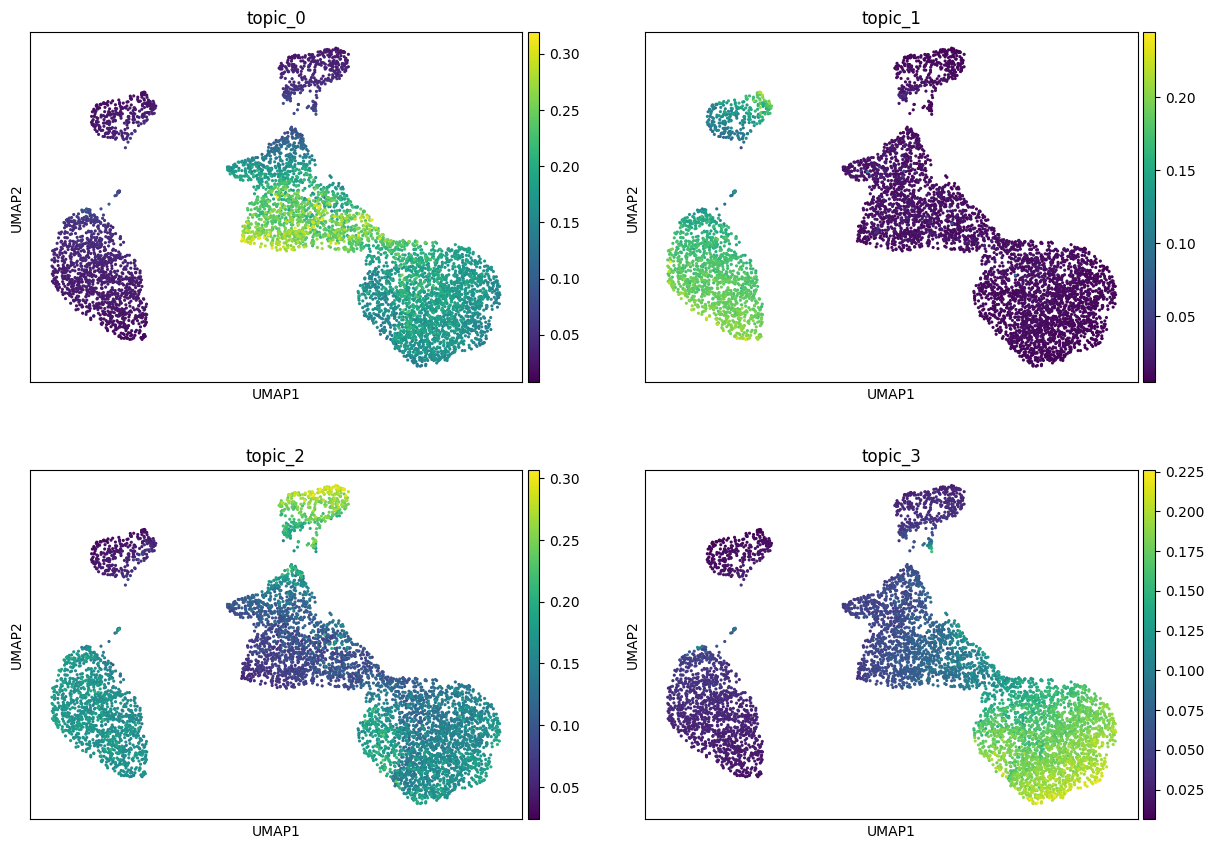

In [60]:
topic_adata = sc.AnnData(theta.values)
topic_adata.obs_names = theta.index
topic_adata.obs[theta.columns] = theta.values
topic_adata.obsm["theta_sqrt"] = np.sqrt(theta.values)

sc.pp.neighbors(topic_adata, use_rep="theta_sqrt", n_neighbors=15)
sc.tl.umap(topic_adata)

show_topics = list(theta.columns[:4])
sc.pl.umap(topic_adata, color=show_topics, ncols=2, cmap="viridis", show=True)

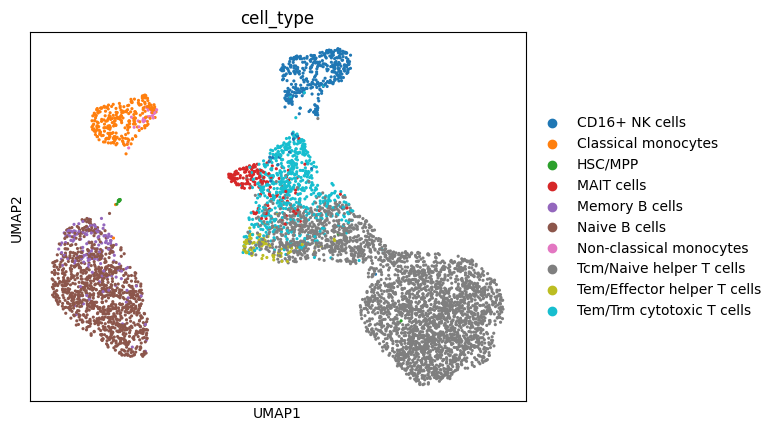

In [61]:
# UMAP of the topic space, coloured by annotated cell type.
# (celltype_key comes from config.yml; here: "celltypist_label")
ct_key = cfg["celltype_key"]
topic_adata.obs["cell_type"] = mdata.mod["rna"].obs[ct_key].astype("category").values
sc.pl.umap(topic_adata, color="cell_type", show=True)

## Topic usage per cell type

Mean topic weight within each cell type highlights which topics mark which
populations. We use the `celltype_key` from the config (falling back to a leiden
clustering of the topic space if it is missing).

In [62]:
def topic_proportions_by_group(theta_df, groups):
    """Mean topic weight per group (e.g. cell type or cluster)."""
    df = theta_df.copy()
    df["__group__"] = pd.Series(list(groups), index=theta_df.index)
    return df.groupby("__group__").mean()


ct_key = cfg.get("celltype_key")
rna_obs = mdata.mod["rna"].obs

groups = rna_obs[ct_key].values
group_name = ct_key

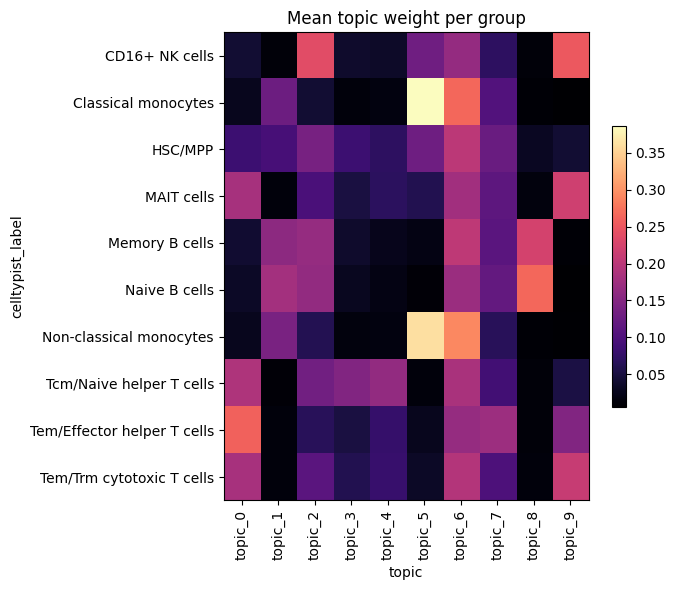

In [63]:
prop = topic_proportions_by_group(theta, groups)

fig, ax = plt.subplots(figsize=(0.5 * theta.shape[1] + 2, 0.4 * prop.shape[0] + 2))
im = ax.imshow(prop.values, aspect="auto", cmap="magma")
ax.set_xticks(range(prop.shape[1]))
ax.set_xticklabels(prop.columns, rotation=90)
ax.set_yticks(range(prop.shape[0]))
ax.set_yticklabels(prop.index)
ax.set_xlabel("topic")
ax.set_ylabel(group_name)
ax.set_title("Mean topic weight per group")
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()